In [1]:
from EpiClockNBL.site_selection import save_unbiased_sites, select_fCpGs
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

Running save-unbiased-sites pipeline with verbose=True, make_figures=True.
Saving figures to /Users/danielmonyak/Documents/Duke/lab/EpiClockNBL/figures_revision
####################################################################################################
####################################################################################################

Directory setup... DONE

Importing and preparing data, will take 2-30 min... DONE

Select unbiased sites...

Selecting CpGs with:
	157 TCGA samples

DONE

Generating figure...

Selecting CpGs with:
	157 TCGA samples

DONE


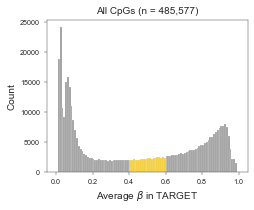

In [2]:
save_unbiased_sites.pipeline(make_figures=True)


Running select-fCpGs pipeline with verbose=True, make_figures=True.
Saving figures to /Users/danielmonyak/Documents/Duke/lab/EpiClockNBL/figures_revision
####################################################################################################
####################################################################################################

Directory setup... DONE

Importing and preparing data...

Starting with 41356 balanced sites

DONE

Importing clinical table... DONE

Removing sites that correlate with patient age...



100%|███████████████████████████████████████████████| 41356/41356 [00:31<00:00, 1298.01it/s]


Picked 19128 non-age-correlated sites

DONE

Selecting final sites...

Picking 1000 target sites
Picked 14346 not stuck sites

DONE

Generating figure... DONE

Generating figure... DONE


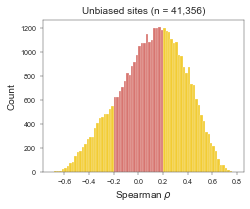

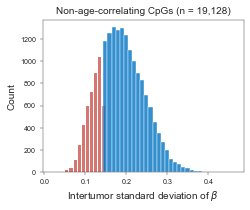

In [3]:
select_fCpGs.pipeline(make_figures=True)

In [4]:
import numpy as np
import pandas as pd
import EpiClockNBL.util as nbl_util
nbl_consts = nbl_util.consts
import os

new_sites = pd.read_table(os.path.join(nbl_consts['official_indir'], 'TARGET', 'NBL.methyl.antiNonIterClustNotStuck_sites.tsv'), index_col=0)
old_sites = pd.read_table(os.path.join(nbl_consts['official_indir'], 'TARGET', 'old data files', 'NBL.methyl.antiNonIterClustNotStuck_sites.tsv'), index_col=0)

In [5]:
c_beta_new = new_sites.std(axis=0)
c_beta_old = old_sites.std(axis=0)

<Axes: >

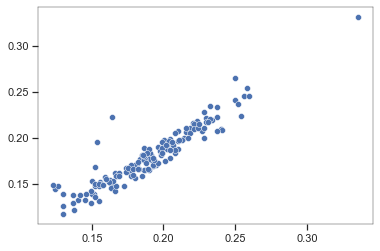

In [6]:
import seaborn as sns
sns.scatterplot(x=c_beta_old, y=c_beta_new)

In [7]:
Clock_CpGs_filepath = os.path.join(nbl_consts['repo_dir'], '3. Select fCpGs', 'outputs', 'NBL_Clock_CpGs.txt')

In [8]:
new_Clock_CpGs = np.loadtxt(os.path.join(nbl_consts['repo_dir'], '3. Select fCpGs', 'outputs', 'NBL_Clock_CpGs.txt'), dtype=str)

In [12]:
# old_Clock_CpGs = old_sites.index.values
old_Clock_CpGs = np.loadtxt(os.path.join(nbl_consts['repo_dir'], '3. Select fCpGs', 'outputs', 'old', 'NBL_Clock_CpGs.txt'), dtype=str)

In [13]:
len(set(new_Clock_CpGs).intersection(set(old_Clock_CpGs)))

336

In [56]:
len(set(new_Clock_CpGs).intersection(set(new_sites.index.values)))

336

In [55]:

len(set(new_Clock_CpGs).intersection(set(old_sites.index.values)))

1000

In [36]:
Clock_CpGs = new_sites.index.values
existing_set = np.loadtxt(Clock_CpGs_filepath, dtype=str)
assert np.all(np.sort(Clock_CpGs) == np.sort(existing_set))

AssertionError: 

In [39]:
import os
import time
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
import EpiClockNBL.util as nbl_util
nbl_consts = nbl_util.consts
from EpiClockNBL.site_selection.util import clusteringWeights, getBinEdges

# IO directories

proj_dir = os.path.join(nbl_consts['official_indir'], 'TARGET')

figure_outdir = os.path.join(nbl_consts['repo_dir'], 'figures_revision')
output_dir = 'outputs'
outfile_dir = os.path.join(output_dir, 'outfiles')
outdir = proj_dir

verbose=True
make_figures=False

if verbose:
    print(f'\nRunning select-fCpGs pipeline with verbose={verbose}, make_figures={make_figures}.')
    time.sleep(1)
    if make_figures:
        print(f'Saving figures to {os.path.abspath(figure_outdir)}')
    else:
        print('Set make_figures=True to generate the accompanying figures.')
    print('#'*100)
    print('#'*100)
    time.sleep(1)

####################################################################################
####################################################################################

# Directory setup
if verbose:
    print('\nDirectory setup...', end=' ')
    time.sleep(1)
        
os.makedirs(figure_outdir, exist_ok=True)
os.makedirs(output_dir, exist_ok=True)
os.makedirs(outfile_dir, exist_ok=True)
os.makedirs(outdir, exist_ok=True)

if verbose:
    print('DONE')

####################################################################################
####################################################################################

# Prepare data
if verbose:
    print('\nImporting and preparing data...', end='\n\n')
    time.sleep(1)

###############################
##### IMPORT/PROCESS DATA #####
###############################

# Import beta values
beta_values_unbiased_sites = pd.read_table(
    os.path.join(proj_dir, 'beta_values_unbiased_sites.txt'),
    index_col=0
)
beta_values_unbiased_sites = beta_values_unbiased_sites.rename(columns=nbl_util.getSampleID)

balanced_CpGs = beta_values_unbiased_sites.index.values
print(f'Starting with {balanced_CpGs.shape[0]} balanced sites')

beta_values_unbiased_sites_original = beta_values_unbiased_sites

if verbose:
    print('\nDONE')

####################################################################################
####################################################################################

# Import clinical table
if verbose:
    print('\nImporting clinical table...', end=' ')
    time.sleep(1)

clinical = pd.read_table(
    os.path.join(proj_dir, 'cohort1.clinical.tsv')
)
clinical = clinical.set_index('submitter_id')

sampleIDs = beta_values_unbiased_sites.columns.values
patient_to_sample_IDs = pd.Series(data=sampleIDs, index=[nbl_util.sampleToPatientID(x) for x in sampleIDs]).rename('sampleID')
clinical = clinical.merge(patient_to_sample_IDs, left_index=True, right_index=True, how='left')

if verbose:
    print('DONE')

####################################################################################
####################################################################################

# Remove sites that correlate with patient age
if verbose:
    print('\nRemoving sites that correlate with patient age...', end='\n\n')
    time.sleep(1)

assert np.all((clinical['age_at_diagnosis'] + clinical['days_to_birth']).dropna() == 0)

spear_corr_list = []
patientID_list = beta_values_unbiased_sites.columns.map(nbl_util.sampleToPatientID)
age_ser = clinical.loc[patientID_list, ['sampleID', 'age_at_diagnosis']].set_index('sampleID').squeeze('columns')
for site in tqdm(beta_values_unbiased_sites.index, miniters=1000):
    spear_corr_list.append(
        spearmanr(
            pd.concat([beta_values_unbiased_sites.loc[site], age_ser], axis=1).dropna()
        ).correlation
    )

spear_corr_ser = pd.Series(index=beta_values_unbiased_sites.index, data=spear_corr_list)

nonCorrelating_sites = spear_corr_ser.index[np.abs(spear_corr_ser) < 0.2]
beta_values_unbiased_sites = beta_values_unbiased_sites.loc[nonCorrelating_sites]

print(f'Picked {nonCorrelating_sites.shape[0]} non-age-correlated sites')

if verbose:
    print('\nDONE')

####################################################################################
####################################################################################

########################
##### SELECT SITES #####
########################
if verbose:
    print('\nSelecting final sites...', end='\n\n')
    time.sleep(1)

# Ideally, 1000 Clock sites selected
# We dont want to select more than half the number of unbiased sites (n)
# If n/2 < 1000, only pick n/2 sites
target_n = min(1000, int(balanced_CpGs.shape[0] / 2))
print(f'Picking {target_n} target sites')

# Calculate inter-tumor stdevs of sites
# Make array of unbiased sites that are not in the lowest 25%
balanced_beta_stdevs = beta_values_unbiased_sites.std(axis=1).dropna()

stdev_threshold = np.quantile(balanced_beta_stdevs, 0.25)

below_data = balanced_beta_stdevs[balanced_beta_stdevs < stdev_threshold]
above_data = balanced_beta_stdevs[balanced_beta_stdevs >= stdev_threshold]

########################################
########################################

balanced_notStuck = balanced_beta_stdevs.index[balanced_beta_stdevs > stdev_threshold].values
print(f'Picked {balanced_notStuck.shape[0]} not stuck sites')
beta_values_unbiased_sites = beta_values_unbiased_sites.loc[balanced_notStuck]

########################################
########################################

# Fill missing values with mean of that site across tumors
km_beta_values = beta_values_unbiased_sites.apply(lambda x:x.fillna(x.mean()), axis=1)

########################################
########################################

# Determine clustering weights
# See local_util for details
clustering_weights_list = [clusteringWeights(km_beta_values, random_state=0) for i in range(50)]
clustering_weights_ser = pd.concat(clustering_weights_list, axis=1).mean(axis=1)

# Only consider sites in balanced_notStuck
# Sort sites by clustering weights and select 1000 (or fewer) sites with the lowest weight
most_random_sites_nonIterNotStuck = clustering_weights_ser.sort_values().index[:target_n].values

# Calculate c_beta using Clock sites
c_beta = 1 - beta_values_unbiased_sites.loc[most_random_sites_nonIterNotStuck].std(axis=0)

########################
###### SAVE FILES ######
########################



Running select-fCpGs pipeline with verbose=True, make_figures=False.
Set make_figures=True to generate the accompanying figures.
####################################################################################################
####################################################################################################

Directory setup... DONE

Importing and preparing data...

Starting with 41356 balanced sites

DONE

Importing clinical table... DONE

Removing sites that correlate with patient age...



100%|███████████████████████████████████████████████| 41356/41356 [00:37<00:00, 1102.02it/s]


Picked 19128 non-age-correlated sites

DONE

Selecting final sites...

Picking 1000 target sites
Picked 14346 not stuck sites


In [65]:

# Reset variable name
Clock_CpGs = most_random_sites_nonIterNotStuck

## Save Clock CpG list
Clock_CpGs_filepath = os.path.join(output_dir, f'NBL_Clock_CpGs.txt')

# Save Clock sites, don't overwrite existing file
if os.path.exists(Clock_CpGs_filepath):
    existing_set = np.loadtxt(Clock_CpGs_filepath, dtype=str)
    assert np.all(np.sort(Clock_CpGs) == np.sort(existing_set))
    print('Current output matches existing file.')
else:
    np.savetxt(Clock_CpGs_filepath, Clock_CpGs, fmt='%s')

Current output matches existing file.


In [41]:
len(set(Clock_CpGs).intersection(existing_set))

1000

In [42]:


## Save c_beta values of final tumors
c_beta_final_samples = c_beta
c_beta_filepath = os.path.join(output_dir, f'NBL.c_beta.txt')

# Save c_beta values, don't overwrite existing file
if os.path.exists(c_beta_filepath):
    existing_c_beta = pd.read_table(c_beta_filepath, index_col=0, header=None).squeeze("columns")
    assert (c_beta_final_samples - existing_c_beta < 1e-6).all()
    print('Current output matches existing file.')
else:
    c_beta_final_samples.to_csv(c_beta_filepath, sep='\t', header=False)

# Save beta values of Clock sites
outfile_path = os.path.join(outdir, f'NBL.methyl.antiNonIterClustNotStuck_sites.tsv')
beta_values_unbiased_sites.loc[Clock_CpGs].to_csv(outfile_path, sep='\t')


Current output matches existing file.


In [43]:
beta_values_new = beta_values_unbiased_sites.loc[Clock_CpGs]

In [ ]:
new_sites

In [51]:
len(set(Clock_CpGs).intersection(set(new_sites.index)))

1000

In [71]:
new_Clock_CpGs = np.loadtxt(os.path.join(nbl_consts['repo_dir'], '3. Select fCpGs', 'outputs', 'NBL_Clock_CpGs.txt'), dtype=str)
new_sites = pd.read_table(os.path.join(nbl_consts['official_indir'], 'TARGET', 'NBL.methyl.antiNonIterClustNotStuck_sites.tsv'), index_col=0)
len(set(new_Clock_CpGs).intersection(set(new_sites.index.values)))

336

In [75]:
Clock_CpGs_filepath 
# == os.path.join(nbl_consts['repo_dir'], '3. Select fCpGs', 'outputs', 'NBL_Clock_CpGs.txt')

'outputs/NBL_Clock_CpGs.txt'

In [72]:
existing_set = np.loadtxt(Clock_CpGs_filepath, dtype=str)

In [67]:
len(set(new_Clock_CpGs).intersection(set(Clock_CpGs)))

336

In [73]:

len(set(new_Clock_CpGs).intersection(set(existing_set)))

336

In [ ]:


if verbose:
    print('\nDONE')

####################################################################################
####################################################################################

if not make_figures:
    return
#
#
#
# Figures
#
#
#

## Configure graph
sf = nbl_consts['sf']
figsize = np.array([9, 7])
sns.set(rc={"savefig.bbox":'tight', 'axes.linewidth':sf}, font_scale=1, style='ticks')

####################################################################################
####################################################################################

# Figure 1
if verbose:
    print('\nGenerating figure...', end=' ')
    time.sleep(1)

num_sites = len(spear_corr_ser)
thresh = 0.2

fig, ax = plt.subplots(figsize=figsize * sf)

binwidth=0.02
bins = np.concatenate([
    getBinEdges(spear_corr_ser.min(), spear_corr_ser.loc[nonCorrelating_sites].min(), binwidth, hardStop=True),
    getBinEdges(spear_corr_ser.loc[nonCorrelating_sites].max(), spear_corr_ser.max(), binwidth, hardStop=False)
])
sns.histplot(ax=ax, x=spear_corr_ser.loc[~np.isin(spear_corr_ser.index, nonCorrelating_sites)],
            color=nbl_consts['palette_jco'][1],
            bins = bins,
            alpha=nbl_consts['opacity'])
sns.histplot(ax=ax, x=spear_corr_ser.loc[nonCorrelating_sites],
            color=nbl_consts['palette_jco'][3], binwidth=binwidth, alpha=nbl_consts['opacity'])

ax.set_xlabel(r'Spearman $\rho$', fontsize=nbl_consts['labelfontsize']*sf)
ax.set_ylabel(ax.get_ylabel(), fontsize=nbl_consts['labelfontsize'] * sf)
ax.set_title(f'Unbiased sites (n = {num_sites:,})', fontsize=nbl_consts['labelfontsize']*sf)
ax.tick_params(axis='both', labelsize=nbl_consts['ticksfontsize'] * sf, width=sf, length=8 * sf)

# Save figure
fig.savefig(os.path.join(figure_outdir, 'remove_age_correlated.svg'), format='svg', pad_inches=0.1)
fig.show()

if verbose:
    print('DONE')

####################################################################################
####################################################################################

# Plot inter-tumor standard deviation of beta for each non-age-correlated site
if verbose:
    print('\nGenerating figure...', end=' ')
    time.sleep(1)

beta_values_nonCorrelating_stds = beta_values_unbiased_sites_original.loc[nonCorrelating_sites].std(axis=1)

# Create plot
fig, ax = plt.subplots(figsize=figsize * sf)

binwidth = 0.01
sns.histplot(ax=ax,      # Non-fluctuating sites
            x=beta_values_nonCorrelating_stds.loc[nonCorrelating_sites[~np.isin(nonCorrelating_sites, balanced_notStuck)]],
            color=nbl_consts['palette_jco'][3], alpha=nbl_consts['opacity'], binwidth=binwidth
            )
sns.histplot(ax=ax,      # Fluctuating sites
            x=beta_values_nonCorrelating_stds.loc[balanced_notStuck],
            color=nbl_consts['palette_jco'][0], alpha=nbl_consts['opacity'], binwidth=binwidth
            )

# Customize figure
ax.set_xlabel('Intertumor standard deviation of $β$', fontsize=nbl_consts['labelfontsize'] * sf)
ax.set_ylabel(ax.get_ylabel(), fontsize=nbl_consts['labelfontsize'] * sf)
ax.set_title(f'Non-age-correlating CpGs (n = {len(nonCorrelating_sites):,})', fontsize=nbl_consts['labelfontsize'] * sf)
ax.tick_params(axis='both', labelsize=nbl_consts['ticksfontsize'] * sf, width=sf, length=8 * sf)

# Save figure
fig.savefig(os.path.join(figure_outdir, 'pick_notStuck_sites.svg'), format='svg', pad_inches=0.1)
fig.show()

if verbose:
    print('DONE')}}